# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
## **Práctica 3 - Parte 2: Análisis de Señales de EEG para Imaginería Motora**
### Laboratorio Bioseñales y sistemas

- Alejandra Hinestroza Chaparro
- María José Ríos Hurtado

### **MARCO TEÓRICO**
El electroencefalograma (EEG) es una técnica de registro de la actividad eléctrica cerebral con alta resolución temporal, ampliamente utilizada en el estudio de interfaces cerebro-computadora (BCI, por sus siglas en inglés). Durante la imaginería motora, definida como la representación mental de un movimiento sin ejecución física del mismo, se producen cambios característicos en los ritmos cerebrales que pueden ser captados mediante EEG (Yu et al., 2022).

Los ritmos más relevantes en este contexto son el ritmo Mu (8-13 Hz) y el ritmo Beta (13-30 Hz), ambos registrados predominantemente en la región sensoriomotora del cerebro. Cuando un sujeto imagina mover una extremidad, se produce una desincronización relacionada con eventos (ERD) en estos ritmos, lo que refleja la activación de la corteza motora contralateral al movimiento imaginado (Yu et al., 2022). Este fenómeno es la base fisiológica que permite distinguir entre la imaginería de mano izquierda y mano derecha mediante el análisis de señales EEG.

Desde el punto de vista de la colocación de electrodos, se utilizó el sistema internacional 10-20, que estandariza la ubicación de los electrodos en el cuero cabelludo. En este sistema, los electrodos C3 y C4 se ubican sobre la corteza motora izquierda y derecha respectivamente, siendo considerados los canales de mayor relevancia para el análisis de imaginería motora de miembros superiores. El electrodo Cz se sitúa en la línea central y también presenta actividad motora relacionada con ambas extremidades (Yin et al., 2016).

Para cuantificar la actividad de cada canal, se calculó el valor RMS (Root Mean Square), una medida ampliamente utilizada en el procesamiento de bioseñales para estimar la potencia promedio de una señal. El RMS se calculó primero para cada época individual y luego se promedió a través de todas las épocas disponibles por sujeto, obteniendo un valor representativo por canal y por clase.

Finalmente, para determinar si las diferencias observadas entre los grupos T1 y T2 eran estadísticamente significativas, se siguió un flujo de validación estándar: primero se verificó la normalidad de los datos con la prueba de Shapiro-Wilk, luego la homocedasticidad con la prueba de Levene, y según los resultados se aplicó una prueba t de Student para muestras independientes o, en caso de no cumplirse los supuestos paramétricos, la prueba no paramétrica U de Mann-Whitney. Se consideró un nivel de significancia de p < 0.05 para identificar los canales con diferencia estadística entre ambas clases de imaginería motora.

### **RESUMEN**

En este trabajo se analizaron señales de EEG registradas durante tareas de imaginería motora de mano izquierda (T1) y mano derecha (T2), obtenidas de la base de datos pública EEG Motor Movement/Imagery Dataset de PhysioNet (Goldberger et al., 2000). Se seleccionaron 10 sujetos (S001, S002, S003, S004, S005, S006, S007, S008, S009, S010) y se procesaron los runs 4, 8 y 12, correspondientes exclusivamente a tareas de imaginería motora, obteniendo aproximadamente 22-23 épocas por clase por sujeto.

Para cada sujeto se calculó el valor RMS promedio por canal sobre todas las épocas disponibles, construyendo dos DataFrames poblacionales de dimensión 10 × 64, uno por clase. Posteriormente se aplicó un flujo de análisis estadístico canal por canal: prueba de normalidad de Shapiro-Wilk, prueba de homocedasticidad de Levene, y según los resultados, prueba t de Student o prueba U de Mann-Whitney. De los 64 canales analizados, 39 no siguieron una distribución normal (Shapiro-Wilk p < 0.05), por lo que en estos casos se aplicó Mann-Whitney, mientras que en los 25 canales restantes se aplicó t de Student. En todos los canales las varianzas resultaron homogéneas (Levene p > 0.05).

El resultado más importante fue que ningún canal alcanzó significancia estadística (p < 0.05), lo que indica que el RMS de banda ancha (1-40 Hz) no logró discriminar entre ambas clases de imaginería motora en esta población. El canal con mayor diferencia relativa entre grupos fue F7 (Cohen's d = 0.1287), aunque este valor se clasifica como un efecto insignificante según los criterios de Cohen (1988), evidenciando las limitaciones del RMS de banda ancha como feature discriminativa para sistemas BCI basados en imaginería motora.

**Importación de librerías necesarias**

In [138]:
import mne
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

**Definición de variables principales**

In [139]:
sujetos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
runs = [4, 8, 12] # Las tareas que deseamos analizar (runs de imaginería motora).
datos = "./DATOS_EEG"  # Ruta de la carpeta con los archivos a analizar.

**Exploración de datos y extracción de información**

Inicialmente se explora el contenido de los archivos a analizar mediante un sólo archivo piloto (en este caso el sujeto 1 y el run 4) principalemnte buscando la nomenclatura y distribución de los eventos para su posterior separación en los grupos correspondientes (T1 y T2).

In [140]:
# GENERACIÓN DE NOMBRE Y RUTA DE ARCHIVO
sujeto = 1
run = 4

nombre_sujeto = f"sub-{sujeto:03d}" # el :03d escribe el número con 3 dígitos, rellenando con ceros     
nombre_archivo = f"S{sujeto:03d}R{run:02d}.edf" # el :02d es igual pero con 2 dígitos

# Ruta completa del archivo
ruta_archivo = f"{datos}/{nombre_sujeto}/{nombre_archivo}"

print("Cargando:", ruta_archivo)

archivo = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
# preload=True --> carga toda la señal en memoria
# verbose=False --> no imprime mensajes innecesarios

print(archivo.info)

Cargando: ./DATOS_EEG/sub-001/S001R04.edf
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [141]:
# LECTURA DE EVENTOS:
# T0 = reposo, T1 = mano izquierda, T2 = mano derecha

eventos, id_eventos = mne.events_from_annotations(archivo, verbose=False)

print("Tipos de eventos:", id_eventos)
print("Total de eventos encontrados:", len(eventos))

Tipos de eventos: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total de eventos encontrados: 30


**Se explora filtrado y corte por épocas en un solo sujeto**

In [142]:
# Filtramos la señal entre 1 y 40 Hz
# Esto elimina:
# - Por debajo de 1 Hz: movimientos lentos del electrodo, respiración
# - Por encima de 40 Hz: ruido muscular, interferencia eléctrica
# Los ritmos de imaginería motora (Mu y Beta) están entre 8 y 30 Hz
# así que con este filtro los conservamos perfectamente
archivo.filter(1.0, 40.0, verbose=False)

# Aquí le decimos a MNE: 
# "recórtame segmentos de señal alrededor de cada evento T1 y T2"

epocas = mne.Epochs(
    archivo,                              # la señal completa
    eventos,                          # eventos que obtuvimos antes
    event_id={'T1': 2, 'T2': 3},     # solo nos interesan T1 y T2, ignoramos T0
    tmin=0.0,                         # empieza justo cuando ocurre el evento
    tmax=4.0,                         # termina 4 segundos después
    baseline=None,                    # no hacemos corrección de baseline
    preload=True,                     # cargamos todo en memoria ya
    verbose=False
)

print("Épocas encontradas:", epocas)
print("Cantidad T1:", len(epocas['T1']))
print("Cantidad T2:", len(epocas['T2']))

Épocas encontradas: <Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.7 MiB, data loaded,
 'T1': 8
 'T2': 7>
Cantidad T1: 8
Cantidad T2: 7


In [143]:
# Separamos las épocas por clase
# get_data() convierte las épocas en un arreglo numérico de NumPy
# con forma (n_epocas, n_canales, n_muestras)

datos_T1 = epocas['T1'].get_data()  # épocas de mano izquierda
datos_T2 = epocas['T2'].get_data()  # épocas de mano derecha

# Veamos las formas de los arreglos
print("Forma datos T1:", datos_T1.shape)
print("Forma datos T2:", datos_T2.shape)

Forma datos T1: (8, 64, 641)
Forma datos T2: (7, 64, 641)


Ahora si, conociendo un poco más los datos, se procede a crear la **función** dentro de la cuál se integrara parte del código de la exploración anterior (que es necesario para la lectura de archivos y el desarrollo siguiente), aplicación de un filtro pasa-banda 
entre 1 y 40 Hz, el cálculo de la RMS para cada época de cada canal de forma individual sobre el eje del tiempo y el promedio de estos valores a través de todas las épocas para obtener un valor representativo del sujeto por cada canal.

In [144]:
def procesar_sujeto(sujeto, runs, datos):
    # listas donde vamos acumulando las épocas de los 3 runs
    epocas_T1_sujeto = []
    epocas_T2_sujeto = []
    nombres_canales = None
    
    for run in runs:
        # armamos la ruta del archivo
        nombre_sujeto = f"sub-{sujeto:03d}"
        nombre_archivo = f"S{sujeto:03d}R{run:02d}.edf"
        ruta_archivo = f"{datos}/{nombre_sujeto}/{nombre_archivo}"
        
        print(f"  Cargando {nombre_archivo}...")
        
        # cargamos y filtramos — igual que antes
        raw = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
        # raw.filter(8.0, 13.0, verbose=False)
        raw.filter(1.0, 40.0, verbose=False)
        # El límite inferior de 1 Hz permite eliminar componentes de 
        # baja frecuencia no relacionadas con la actividad neuronal de interés, como la 
        # deriva lenta de la línea base producida por movimientos de los electrodos, 
        # artefactos de sudoración o variaciones lentas de la impedancia electrodo-piel. 
        # El límite superior de 40 Hz permite eliminar ruido de alta frecuencia, 
        # principalmente artefactos de origen muscular (EMG) que pueden contaminar la 
        # señal EEG y dificultar su interpretación.
        
        # leemos los eventos — igual que antes
        eventos, id_eventos = mne.events_from_annotations(raw, verbose=False)
        
        # cortamos las épocas — igual que antes
        epocas = mne.Epochs(
            raw,
            eventos,
            event_id={'T1': 2, 'T2': 3},
            tmin=0.0,
            tmax=4.0,
            baseline=None,
            preload=True,
            verbose=False
        )
        
        # guardamos los nombres de los canales solo la primera vez
        if nombres_canales is None:
            nombres_canales = [ch.strip('.') for ch in epocas.ch_names]
        
        epocas_T1_sujeto.append(epocas['T1'].get_data())
        epocas_T2_sujeto.append(epocas['T2'].get_data())
    
    todos_T1 = np.concatenate(epocas_T1_sujeto, axis=0)
    todos_T2 = np.concatenate(epocas_T2_sujeto, axis=0)
    
    rms_T1 = np.mean(np.sqrt(np.mean(todos_T1**2, axis=2)), axis=0)
    rms_T2 = np.mean(np.sqrt(np.mean(todos_T2**2, axis=2)), axis=0)
    
    print(f"  ✓ Sujeto {sujeto} listo — T1:{todos_T1.shape[0]} épocas, T2:{todos_T2.shape[0]} épocas")
    
    return rms_T1, rms_T2, nombres_canales  

**Se hace uso de la función anterior dentro de un loop para los 10 sujetos para la organización de la información en un DataFrame**

In [145]:
# listas para ir guardando los resultados de cada sujeto
resultados_T1 = {}
resultados_T2 = {}
nombres_canales = None

# loop sobre los 10 sujetos
for sujeto in sujetos:
    print(f"\nProcesando sujeto {sujeto}...")
    
    rms_T1, rms_T2, nombres_canales = procesar_sujeto(sujeto, runs, datos)
    
    # guardamos con el nombre del sujeto como llave
    resultados_T1[f"S{sujeto:03d}"] = rms_T1
    resultados_T2[f"S{sujeto:03d}"] = rms_T2

# construimos los DataFrames
# cada fila = un sujeto, cada columna = un canal
df_T1 = pd.DataFrame(resultados_T1, index=nombres_canales).T
df_T2 = pd.DataFrame(resultados_T2, index=nombres_canales).T

print("\n✓ DataFrames construidos!")
print("Forma:", df_T1.shape, "/ filas=sujetos, columnas=canales")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)  # para que muestre todos los canales

print("\nDataFrame Mano Izquierda (T1):")
display(df_T1.round(6))

print("\nDataFrame Mano Derecha (T2):")
display(df_T2.round(6))


Procesando sujeto 1...
  Cargando S001R04.edf...
  Cargando S001R08.edf...
  Cargando S001R12.edf...
  ✓ Sujeto 1 listo — T1:23 épocas, T2:22 épocas

Procesando sujeto 2...
  Cargando S002R04.edf...
  Cargando S002R08.edf...
  Cargando S002R12.edf...
  ✓ Sujeto 2 listo — T1:23 épocas, T2:22 épocas

Procesando sujeto 3...
  Cargando S003R04.edf...
  Cargando S003R08.edf...
  Cargando S003R12.edf...
  ✓ Sujeto 3 listo — T1:23 épocas, T2:22 épocas

Procesando sujeto 4...
  Cargando S004R04.edf...
  Cargando S004R08.edf...
  Cargando S004R12.edf...
  ✓ Sujeto 4 listo — T1:23 épocas, T2:22 épocas

Procesando sujeto 5...
  Cargando S005R04.edf...
  Cargando S005R08.edf...
  Cargando S005R12.edf...
  ✓ Sujeto 5 listo — T1:21 épocas, T2:24 épocas

Procesando sujeto 6...
  Cargando S006R04.edf...
  Cargando S006R08.edf...
  Cargando S006R12.edf...
  ✓ Sujeto 6 listo — T1:24 épocas, T2:21 épocas

Procesando sujeto 7...
  Cargando S007R04.edf...
  Cargando S007R08.edf...
  Cargando S007R12.edf..

,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
S001,0.000037,0.000039,0.000041,0.000042,0.000040,0.000035,0.000030,0.000036,0.000039,0.000041,0.000043,0.000041,0.000035,0.000029,0.000037,0.000040,0.000042,0.000043,0.000040,0.000038,0.000032,0.000046,0.000040,0.000041,0.000046,0.000044,0.000039,0.000037,0.000040,0.000039,0.000044,0.000038,0.000041,0.000041,0.000038,0.000037,0.000033,0.000031,0.000035,0.000024,0.000034,0.000027,0.000034,0.000017,0.000034,0.000025,0.000037,0.000039,0.000041,0.000042,0.000043,0.000041,0.000038,0.000034,0.000031,0.000041,0.000042,0.000044,0.000040,0.000040,0.000044,0.000043,0.000044,0.000040
S002,0.000018,0.000018,0.000019,0.000019,0.000018,0.000016,0.000014,0.000017,0.000018,0.000019,0.000020,0.000018,0.000015,0.000013,0.000017,0.000018,0.000019,0.000020,0.000018,0.000015,0.000013,0.000023,0.000022,0.000021,0.000028,0.000020,0.000020,0.000018,0.000020,0.000022,0.000020,0.000019,0.000019,0.000019,0.000018,0.000018,0.000018,0.000017,0.000018,0.000013,0.000022,0.000013,0.000015,0.000009,0.000015,0.000010,0.000016,0.000018,0.000019,0.000019,0.000020,0.000019,0.000017,0.000015,0.000012,0.000018,0.000020,0.000024,0.000018,0.000017,0.000022,0.000018,0.000023,0.000018
S003,0.000053,0.000052,0.000051,0.000050,0.000050,0.000046,0.000046,0.000043,0.000044,0.000045,0.000046,0.000044,0.000041,0.000039,0.000042,0.000042,0.000043,0.000043,0.000042,0.000039,0.000033,0.000119,0.000109,0.000124,0.000118,0.000087,0.000076,0.000095,0.000097,0.000072,0.000072,0.000064,0.000061,0.000060,0.000066,0.000065,0.000078,0.000072,0.000052,0.000039,0.000042,0.000032,0.000038,0.000021,0.000039,0.000034,0.000039,0.000040,0.000040,0.000041,0.000041,0.000039,0.000038,0.000034,0.000031,0.000040,0.000040,0.000040,0.000037,0.000035,0.000040,0.000038,0.000038,0.000035
S004,0.000018,0.000018,0.000025,0.000015,0.000015,0.000015,0.000015,0.000016,0.000016,0.000016,0.000015,0.000015,0.000015,0.000015,0.000018,0.000015,0.000015,0.000015,0.000014,0.000015,0.000014,0.000019,0.000018,0.000020,0.000024,0.000023,0.000019,0.000017,0.000026,0.000027,0.000022,0.000021,0.000017,0.000015,0.000015,0.000015,0.000017,0.000023,0.000019,0.000149,0.000016,0.000012,0.000016,0.000012,0.000015,0.000013,0.000015,0.000014,0.000015,0.000015,0.000015,0.000016,0.000014,0.000013,0.000011,0.000014,0.000014,0.000015,0.000013,0.000012,0.000013,0.000013,0.000012,0.000012
S005,0.000037,0.000018,0.000018,0.000019,0.000020,0.000021,0.000021,0.000018,0.000016,0.000017,0.000017,0.000017,0.000015,0.000019,0.000029,0.000016,0.000017,0.000016,0.000016,0.000015,0.000026,0.000029,0.000024,0.000027,0.000035,0.000024,0.000021,0.000027,0.000030,0.000037,0.000033,0.000023,0.000020,0.000019,0.000020,0.000020,0.000025,0.000032,0.000023,0.000013,0.000026,0.000017,0.000017,0.000022,0.000033,0.000014,0.000019,0.000021,0.000015,0.000017,0.000016,0.000015,0.000015,0.000018,0.000018,0.000020,0.000015,0.000016,0.000014,0.000022,0.000015,0.000015,0.000013,0.000015
S006,0.000026,0.000019,0.000019,0.000018,0.000018,0.000017,0.000019,0.000018,0.000018,0.000018,0.000017,0.000017,0.000016,0.000011,0.000016,0.000017,0.000017,0.000017,0.000016,0.000016,0.000013,0.000042,0.000028,0.000030,0.000033,0.000033,0.000021,0.000028,0.000028,0.000022,0.000019,0.000019,0.000019,0.000019,0.000018,0.000018,0.000024,0.000028,0.000034,0.000011,0.000022,0.000011,0.000017,0.000011,0.000017,0.000011,0.000014,0.000014,0.000015,0.000015,0.000016,0.000016,0.000013,0.000014,0.000011,0.000014,0.000014,0.000015,0.000014,0.000014,0.000014,0.000015,0.000015,0.000013
S007,0.000023,0.000023,0.000023,0.000021,0.000021,0.000021,0.000017,0.000022,0.000023,0.000023,0.000022,0.000020,0.000019,0.000015,0.000023,0.000024,0.000024,0.000024,0.000022,0.000022,0.000017,0.000028,0.000025,0.000025,0.000034,0.000025,0.000023,0.000024,0.000025,0.000026,0.000027,0.000


DataFrame Mano Derecha (T2):


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
S001,0.000040,0.000042,0.000043,0.000044,0.000042,0.000037,0.000031,0.000038,0.000041,0.000043,0.000044,0.000042,0.000036,0.000030,0.000039,0.000041,0.000043,0.000043,0.000041,0.000039,0.000033,0.000060,0.000052,0.000054,0.000056,0.000054,0.000045,0.000043,0.000048,0.000044,0.000048,0.000042,0.000045,0.000045,0.000042,0.000041,0.000036,0.000034,0.000038,0.000024,0.000036,0.000027,0.000035,0.000018,0.000036,0.000026,0.000039,0.000041,0.000042,0.000044,0.000044,0.000042,0.000040,0.000035,0.000031,0.000043,0.000043,0.000045,0.000041,0.000041,0.000045,0.000044,0.000045,0.000041
S002,0.000017,0.000018,0.000019,0.000020,0.000018,0.000017,0.000014,0.000016,0.000017,0.000020,0.000020,0.000018,0.000015,0.000013,0.000017,0.000018,0.000018,0.000020,0.000018,0.000016,0.000013,0.000020,0.000019,0.000019,0.000022,0.000018,0.000019,0.000018,0.000019,0.000019,0.000019,0.000018,0.000019,0.000019,0.000018,0.000018,0.000017,0.000018,0.000016,0.000013,0.000022,0.000013,0.000014,0.000009,0.000015,0.000010,0.000015,0.000018,0.000018,0.000018,0.000019,0.000019,0.000017,0.000015,0.000012,0.000017,0.000019,0.000022,0.000018,0.000017,0.000022,0.000018,0.000024,0.000018
S003,0.000052,0.000050,0.000050,0.000050,0.000050,0.000049,0.000049,0.000041,0.000043,0.000044,0.000045,0.000043,0.000042,0.000040,0.000040,0.000041,0.000042,0.000042,0.000041,0.000038,0.000033,0.000121,0.000114,0.000132,0.000117,0.000088,0.000079,0.000104,0.000106,0.000067,0.000069,0.000063,0.000061,0.000061,0.000071,0.000070,0.000086,0.000083,0.000048,0.000043,0.000039,0.000034,0.000035,0.000022,0.000037,0.000032,0.000038,0.000039,0.000040,0.000041,0.000041,0.000039,0.000037,0.000034,0.000030,0.000041,0.000041,0.000040,0.000037,0.000035,0.000042,0.000038,0.000038,0.000034
S004,0.000016,0.000016,0.000026,0.000014,0.000014,0.000015,0.000015,0.000014,0.000015,0.000015,0.000015,0.000015,0.000015,0.000015,0.000017,0.000014,0.000015,0.000015,0.000014,0.000015,0.000013,0.000017,0.000016,0.000019,0.000021,0.000022,0.000018,0.000017,0.000025,0.000023,0.000020,0.000019,0.000016,0.000014,0.000015,0.000015,0.000016,0.000022,0.000016,0.000147,0.000013,0.000012,0.000013,0.000012,0.000013,0.000012,0.000014,0.000013,0.000014,0.000015,0.000015,0.000016,0.000014,0.000013,0.000011,0.000013,0.000014,0.000015,0.000013,0.000012,0.000013,0.000013,0.000012,0.000012
S005,0.000041,0.000020,0.000020,0.000021,0.000021,0.000022,0.000021,0.000020,0.000018,0.000020,0.000019,0.000018,0.000016,0.000019,0.000031,0.000018,0.000018,0.000018,0.000017,0.000016,0.000029,0.000030,0.000025,0.000028,0.000035,0.000026,0.000023,0.000027,0.000032,0.000036,0.000035,0.000025,0.000022,0.000021,0.000021,0.000021,0.000026,0.000033,0.000024,0.000013,0.000027,0.000018,0.000018,0.000022,0.000035,0.000014,0.000020,0.000022,0.000017,0.000019,0.000017,0.000017,0.000017,0.000019,0.000019,0.000020,0.000017,0.000017,0.000016,0.000023,0.000016,0.000017,0.000015,0.000015
S006,0.000026,0.000019,0.000019,0.000018,0.000017,0.000017,0.000020,0.000018,0.000018,0.000018,0.000018,0.000017,0.000016,0.000011,0.000017,0.000017,0.000017,0.000017,0.000016,0.000015,0.000013,0.000041,0.000025,0.000027,0.000032,0.000031,0.000019,0.000027,0.000028,0.000021,0.000018,0.000018,0.000018,0.000018,0.000018,0.000018,0.000023,0.000029,0.000034,0.000011,0.000022,0.000011,0.000018,0.000011,0.000017,0.000011,0.000014,0.000014,0.000016,0.000016,0.000016,0.000016,0.000013,0.000013,0.000011,0.000014,0.000015,0.000015,0.000013,0.000013,0.000015,0.000015,0.000014,0.000013
S007,0.000023,0.000024,0.000024,0.000023,0.000023,0.000023,0.000018,0.000023,0.000023,0.000024,0.000024,0.000022,0.000021,0.000016,0.000023,0.000024,0.000025,0.000025,0.000024,0.000024,0.000019,0.000029,0.000027,0.000029,0.000034,0.000026,0.000025,0.000029,0.000030,0.000026,0.000027,0.000

**PRUEBAS ESTADÍSTICAS**

In [146]:
resultados = []  # lista vacía donde vamos guardando los resultados de cada canal

for canal in df_T1.columns:  # recorremos los 64 canales uno por uno
    
    # extraemos los 10 valores RMS de este canal (uno por sujeto)
    grupo_T1 = df_T1[canal].values  # shape (10,) — mano izquierda
    grupo_T2 = df_T2[canal].values  # shape (10,) — mano derecha
    
    # ── Paso 1: Shapiro-Wilk ─────────────────────────────────
    # pregunta: ¿estos 10 valores se distribuyen normalmente?
    # shapiro() devuelve dos cosas: el estadístico y el p-valor
    # el _ significa "no me interesa guardar el estadístico, solo el p-valor"
    # H0: los datos son normales → se rechaza si p < 0.05
    _, p_shapiro_T1 = stats.shapiro(grupo_T1)
    _, p_shapiro_T2 = stats.shapiro(grupo_T2)
    
    # ambos_normales es True solo si LOS DOS grupos pasan la prueba
    ambos_normales = (p_shapiro_T1 > 0.05) and (p_shapiro_T2 > 0.05)
    
    # ── Paso 2: Levene ───────────────────────────────────────
    # pregunta: ¿las varianzas de T1 y T2 son similares?
    # H0: las varianzas son iguales → se rechaza si p < 0.05
    _, p_levene = stats.levene(grupo_T1, grupo_T2)
    varianzas_iguales = p_levene > 0.05
    
    # ── Paso 3: Prueba de hipótesis ──────────────────────────
    # según el enunciado: dos caminos posibles
    if ambos_normales and varianzas_iguales:
        # se cumplen AMBOS supuestos → t-Student
        # equal_var=True porque Levene confirmó varianzas iguales
        _, p_final = stats.ttest_ind(grupo_T1, grupo_T2, equal_var=True)
        prueba = "t-Student"
    else:
        # no se cumple algún supuesto → Mann-Whitney U
        # alternative='two-sided' porque no sabemos si T1 > T2 o T2 > T1
        _, p_final = stats.mannwhitneyu(grupo_T1, grupo_T2, 
                                        alternative='two-sided')
        prueba = "Mann-Whitney"
    
    # guardamos todos los resultados de este canal en un diccionario
    resultados.append({
        'Canal':         canal,
        'p_shapiro_T1':  round(p_shapiro_T1, 4),
        'p_shapiro_T2':  round(p_shapiro_T2, 4),
        'Normal':        ambos_normales,
        'p_levene':      round(p_levene, 4),
        'Var_iguales':   varianzas_iguales,
        'Prueba':        prueba,
        'p_valor':       round(p_final, 4),
        'Significativo': p_final < 0.05
    })

# convertimos la lista de diccionarios en un DataFrame
df_resultados = pd.DataFrame(resultados)

print("=" * 60)
print("RESULTADOS DEL ANÁLISIS ESTADÍSTICO — TODOS LOS CANALES")
print("=" * 60)

pd.set_option('display.max_rows', None)
display(df_resultados)

RESULTADOS DEL ANÁLISIS ESTADÍSTICO — TODOS LOS CANALES


,Canal,p_shapiro_T1,p_shapiro_T2,Normal,p_levene,Var_iguales,Prueba,p_valor,Significativo
0,Fc5,0.2250,0.2671,True,0.9399,True,t-Student,0.9357,False
1,Fc3,0.0176,0.0145,False,0.9030,True,Mann-Whitney,0.9097,False
2,Fc1,0.0294,0.0415,False,0.8761,True,Mann-Whitney,0.9698,False
3,Fcz,0.0092,0.0135,False,0.9044,True,Mann-Whitney,0.9698,False
4,Fc2,0.0250,0.0387,False,0.9491,True,Mann-Whitney,1.0000,False
5,Fc4,0.0460,0.0495,False,0.9748,True,Mann-Whitney,0.8501,False
6,Fc6,0.0092,0.0123,False,0.9919,True,Mann-Whitney,0.8501,False
7,C5,0.0269,0.0430,False,0.9309,True,Mann-Whitney,0.9698,False
8,C3,0.0117,0.0190,False,0.9197,True,Mann-Whitney,1.0000,False
9,C1,0.0103,0.0192,False,0.8968,True,Mann-Whitney,1.0000,False


Dado que ningún canal alcanzó significancia estadística (p < 0.05), se complementó el análisis con el cálculo del tamaño del efecto mediante la d de Cohen. Esta métrica cuantifica qué tan grande es la diferencia entre dos grupos en términos de sus desviaciones estándar combinadas, de manera independiente al tamaño de la muestra.

Su fórmula es:
    **d = |media_T1 - media_T2| / desviación_estándar_combinada**

Según Cohen (1988), los valores se interpretan así:
- d < 0.2  → efecto insignificante
- d > 0.2  → efecto pequeño
- d > 0.5  → efecto mediano
- d > 0.8  → efecto grande

Esta métrica permite identificar los canales con mayor diferencia relativa entre T1 y T2, que serían los candidatos más informativos para un sistema BCI aunque no hayan alcanzado el umbral de significancia estadística con n=10 sujetos.

In [147]:
# ── Canales significativos ───────────────────────────────────
print("=" * 60)
print("CANALES SIGNIFICATIVOS (p < 0.05)")
print("=" * 60)

df_significativos = df_resultados[
    df_resultados['Significativo'] == True
].sort_values('p_valor')

if df_significativos.empty:
    print("Ningún canal alcanzó significancia estadística (p < 0.05)")
else:
    display(df_significativos)

def cohens_d(g1, g2):
    diff = abs(g1.mean() - g2.mean())  # diferencia de medias
    # desviación estándar combinada (pooled):
    # promedia las varianzas de ambos grupos y saca la raíz
    std_pooled = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return round(diff / std_pooled, 4)

efectos = []
for canal in df_T1.columns:
    d = cohens_d(df_T1[canal].values, df_T2[canal].values)
    
    # recuperamos el p-valor y la prueba usada para este canal
    fila = df_resultados[df_resultados['Canal'] == canal]
    p = fila['p_valor'].values[0]
    prueba = fila['Prueba'].values[0]
    
    efectos.append({
        'Canal':   canal,
        'Prueba':  prueba,
        'p_valor': p,
        'Cohen_d': d,
        # clasificamos el tamaño del efecto según Cohen (1988)
        'Magnitud': 'grande'  if d > 0.8 else
                    'mediano' if d > 0.5 else
                    'pequeño' if d > 0.2 else
                    'insignificante'
    })

df_efectos = pd.DataFrame(efectos).sort_values('Cohen_d', ascending=False)

print()
print("=" * 60)
print("TOP 10 CANALES MÁS REPRESENTATIVOS (Cohen's d)")
print("=" * 60)
display(df_efectos.head(10))

CANALES SIGNIFICATIVOS (p < 0.05)
Ningún canal alcanzó significancia estadística (p < 0.05)

TOP 10 CANALES MÁS REPRESENTATIVOS (Cohen's d)


,Canal,Prueba,p_valor,Cohen_d,Magnitud
29,F7,Mann-Whitney,0.5708,0.1287,insignificante
38,Ft7,t-Student,0.8406,0.0962,insignificante
37,F8,Mann-Whitney,0.7337,0.0878,insignificante
30,F5,Mann-Whitney,0.7913,0.0874,insignificante
55,Po7,t-Student,0.8696,0.0785,insignificante
24,Af7,Mann-Whitney,0.9097,0.0706,insignificante
42,T9,Mann-Whitney,0.8501,0.0686,insignificante
31,F3,Mann-Whitney,0.8501,0.0574,insignificante
28,Af8,Mann-Whitney,0.8501,0.0566,insignificante
20,Cp6,t-Student,0.9074,0.0556,insignificante


**Visualización del canal más significativo**

C:\Users\mrios\AppData\Local\Temp\ipykernel_10820\891805654.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


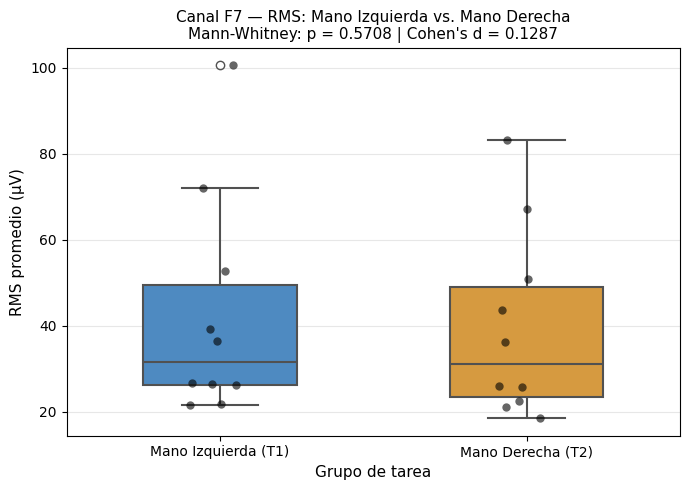

In [148]:
# tomamos el canal con mayor Cohen's d (el más representativo)
canal_top = df_efectos.iloc[0]['Canal']
p_top     = df_efectos.iloc[0]['p_valor']
d_top     = df_efectos.iloc[0]['Cohen_d']
prueba_top = df_efectos.iloc[0]['Prueba']

# armamos un DataFrame en formato largo para seaborn
# multiplicamos por 1e6 para convertir de voltios a microvoltios (µV)
datos_boxplot = pd.DataFrame({
    'RMS': np.concatenate([
        df_T1[canal_top].values * 1e6,   # 10 valores T1 en µV
        df_T2[canal_top].values * 1e6    # 10 valores T2 en µV
    ]),
    'Grupo': ['Mano Izquierda (T1)'] * 10 + ['Mano Derecha (T2)'] * 10
})

fig, ax = plt.subplots(figsize=(7, 5))

# boxplot: muestra la distribución de los 10 valores por grupo
sns.boxplot(
    data=datos_boxplot,
    x='Grupo', y='RMS',
    palette=['#3B8BD4', '#EF9F27'],  # azul para T1, ámbar para T2
    width=0.5,
    linewidth=1.5,
    ax=ax
)

# stripplot: superpone los puntos individuales (un punto = un sujeto)
# así se ve exactamente dónde cae cada sujeto dentro de la caja
sns.stripplot(
    data=datos_boxplot,
    x='Grupo', y='RMS',
    color='black',
    size=6,
    alpha=0.6,   # un poco transparentes para que no tapen la caja
    jitter=True, # los desplaza horizontalmente para que no se encimen
    ax=ax
)

ax.set_title(
    f'Canal {canal_top} — RMS: Mano Izquierda vs. Mano Derecha\n'
    f'{prueba_top}: p = {p_top:.4f} | Cohen\'s d = {d_top}',
    fontsize=11
)
ax.set_xlabel('Grupo de tarea', fontsize=11)
ax.set_ylabel('RMS promedio (µV)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'boxplot_{canal_top}.png', dpi=150, bbox_inches='tight')
plt.show()

### **DISCUSIÓN**

El análisis estadístico realizado sobre los valores RMS promedio de 64 canales EEG en 10 sujetos no reveló diferencias significativas entre la imaginería motora de mano izquierda (T1) y mano derecha (T2) en ningún canal (p > 0.05 en todos los casos).

Respecto a los supuestos estadísticos, se encontró que la mayoría de canales no siguieron una distribución normal según la prueba de Shapiro-Wilk, por lo que en estos casos se aplicó la prueba no paramétrica U de Mann-Whitney. Para los canales que sí cumplieron normalidad y homocedasticidad (prueba de Levene), se aplicó la prueba t de Student para muestras independientes. En todos los canales, la prueba de Levene indicó varianzas homogéneas entre grupos (p > 0.05).

La ausencia de significancia estadística puede atribuirse a tres factores principales. En primer lugar, el tamaño muestral reducido (n=10) limita el poder estadístico de las pruebas para detectar diferencias pequeñas entre grupos. En segundo lugar, el RMS calculado sobre la banda completa (1-40 Hz) refleja principalmente la amplitud general de la señal EEG de cada sujeto, la cual está determinada por factores anatómicos individuales como el grosor del cráneo y las propiedades de conducción eléctrica del tejido, y no exclusivamente por la tarea cognitiva realizada. Como consecuencia, las diferencias de amplitud entre sujetos son mucho mayores que las diferencias entre las clases T1 y T2 dentro de un mismo sujeto. En tercer lugar, la literatura señala que las diferencias entre imaginería de mano izquierda y derecha son más pronunciadas en bandas de frecuencia específicas como Mu (8-13 Hz) y Beta (13-30 Hz), donde ocurre la desincronización relacionada con eventos (ERD), que en la banda completa (Yu et al., 2022).

El análisis complementario mediante la d de Cohen reveló que, aunque ningún canal fue estadísticamente significativo, el canal F7 presentó el mayor tamaño del efecto (d=0.1287), seguido por Ft7 (d=0.0962) y F8 (d=0.0878). Sin embargo, todos los valores de Cohen's d fueron menores a 0.2, clasificándose como efectos insignificantes según los criterios de Cohen (1988). Llamativamente, los canales motores clásicos C3 y C4, ampliamente reportados en la literatura como los más relevantes para imaginería motora de miembros superiores (Yin et al., 2016), no figuraron entre los más informativos en este análisis, lo que refuerza la hipótesis de que el RMS de banda ancha no es la métrica más adecuada para este tipo de discriminación.

### **CONCLUSIONES**

1. El análisis estadístico del RMS promedio por canal no identificó canales con diferencia significativa (p < 0.05) entre la imaginería motora de mano izquierda y derecha en la población de 10 sujetos estudiada. Este resultado sugiere que el RMS calculado sobre la banda completa (1-40 Hz) presenta limitaciones como feature discriminativa para este tipo de tarea, dado que captura la energía global de la señal y es altamente sensible a las diferencias de amplitud inter-sujeto, las cuales superan en magnitud las diferencias funcionales entre clases.

2. La alta variabilidad inter-sujeto observada en los valores de RMS constituye el principal factor que limita la capacidad discriminativa del análisis. Las diferencias anatómicas y fisiológicas entre individuos generan variaciones de amplitud que dominan sobre las diferencias entre tareas de imaginería motora, lo que plantea la necesidad de aplicar estrategias de normalización inter-sujeto o de incrementar el tamaño muestral para obtener resultados más robustos en futuros análisis.

3. Para el desarrollo de un sistema BCI basado en imaginería motora, se recomienda considerar métricas espectrales específicas como la potencia en banda Mu (8-13 Hz) o Beta (13-30 Hz), las cuales capturan directamente el fenómeno de desincronización relacionada con eventos (ERD) descrito en la literatura (Yu et al., 2022; Yin et al., 2016). Adicionalmente, incrementar el tamaño muestral más allá de 10 sujetos mejoraría el poder estadístico de las pruebas y permitiría detectar diferencias entre clases que con muestras pequeñas no alcanzan significancia estadística.

### **REFERENCIAS**

- Cohen, J. (1988). Statistical power analysis for the behavioral sciences (2nd ed.). Lawrence Erlbaum Associates.

- Goldberger, A. L., Amaral, L. A. N., Glass, L., Hausdorff, J. M., Ivanov, P. C., Mark, R. G., Mietus, J. E., Moody, G. B., Peng, C. K., & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation, 101(23), e215-e220. https://doi.org/10.1161/01.CIR.101.23.e215

- Yu, H., Ba, S., Guo, Y., Guo, L., & Xu, G. (2022). Effects of motor imagery tasks on brain functional networks based on EEG Mu/Beta rhythm. Brain Sciences, 12(2), 194. https://doi.org/10.3390/brainsci12020194

- Yin, S., Liu, Y., & Ding, M. (2016). Amplitude of sensorimotor Mu rhythm is correlated with BOLD from multiple brain regions: A simultaneous EEG-fMRI study. Frontiers in Human Neuroscience, 10, 364. https://doi.org/10.3389/fnhum.2016.00364